In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import pickle
import os

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

# Load and clean data
df = pd.read_csv('../data/raw/symptoms.csv')
symptom_cols = [col for col in df.columns if col.startswith('Symptom')]
df['symptoms'] = df[symptom_cols].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)
df = df[['symptoms', 'Disease']].rename(columns={'Disease': 'prognosis'})
print("✅ Data loaded!", df.shape)
print(df.head(3))

✅ Data loaded! (313, 2)
                                            symptoms prognosis
0   muscle_wasting  patches_in_throat  high_fever...      AIDS
1   patches_in_throat  high_fever  extra_marital_...      AIDS
2   muscle_wasting  high_fever  extra_marital_con...      AIDS


In [2]:
# Train symptom classifier
X = df['symptoms']
y = df['prognosis']

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_vec = vectorizer.fit_transform(X)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y_enc, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"✅ Symptom Model Accuracy: {acc:.2%}")

✅ Symptom Model Accuracy: 100.00%


In [3]:
# Save symptom models
with open('../models/symptom_classifier.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('../models/symptom_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('../models/disease_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ Symptom models saved!")

✅ Symptom models saved!


C:\Users\iaayu\AppData\Local\Temp\ipykernel_2712\1576059316.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_counts.values, y=disease_counts.index,


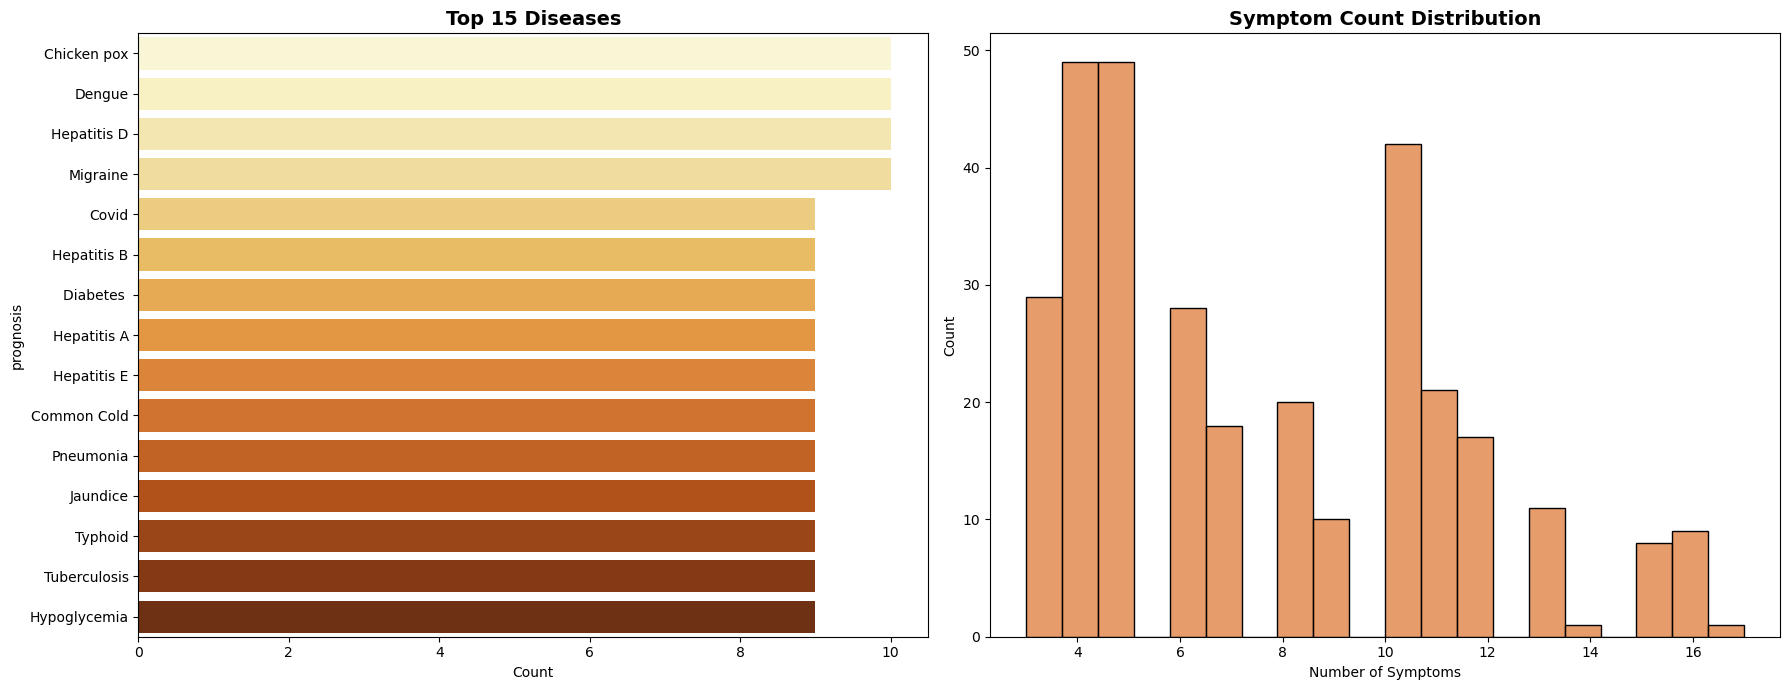

✅ Charts saved!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# EDA Charts
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1: Top diseases
disease_counts = df['prognosis'].value_counts().head(15)
sns.barplot(x=disease_counts.values, y=disease_counts.index, 
            palette='YlOrBr', ax=axes[0])
axes[0].set_title('Top 15 Diseases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

# Chart 2: Symptom count distribution
df['symptom_count'] = df['symptoms'].apply(lambda x: len(x.split()))
sns.histplot(df['symptom_count'], bins=20, color='#E07B39', ax=axes[1])
axes[1].set_title('Symptom Count Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Symptoms')

plt.tight_layout()
plt.savefig('../reports/figures/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved!")

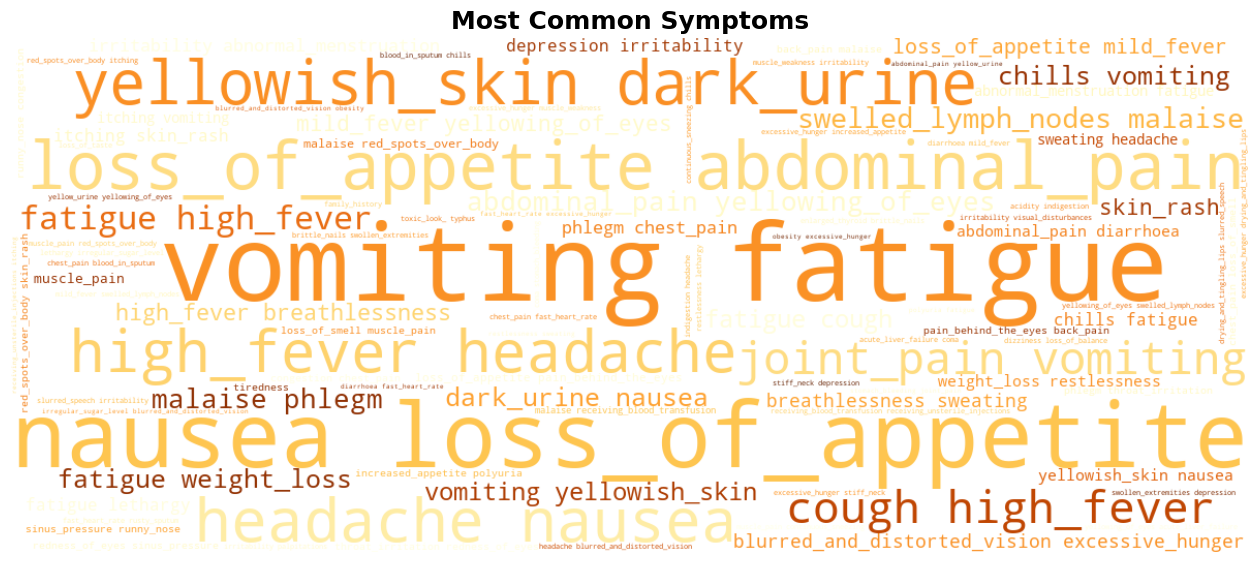

✅ Wordcloud saved!


In [5]:
from wordcloud import WordCloud

all_symptoms = ' '.join(df['symptoms'].astype(str).tolist())
wordcloud = WordCloud(
    width=1200, height=500,
    background_color='white',
    colormap='YlOrBr',
    max_words=100
).generate(all_symptoms)

plt.figure(figsize=(16, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Symptoms', fontsize=18, fontweight='bold')
plt.savefig('../reports/figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Wordcloud saved!")